Netflix plays a important role in global entertainment, offering thousands of movies and TV shows to millions of subscribers. This EDA explores a dataset containing listings of movies and tv shows on Netflix, aiming to uncover trends in content type, genres, countries, release patterns, ratings, and more — providing insights into Netflix's content strategy and viewer preferences.

## Loading package

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

In [2]:
pip install ax-platform

Note: you may need to restart the kernel to use updated packages.


## First view on the data

In [3]:
df_all=pd.read_csv('netflix_titles.csv')

In [4]:
df_all.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df_all.shape

(8807, 12)

In [6]:
df_all.keys()

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## Analysis on content types

<Axes: xlabel='type', ylabel='count'>

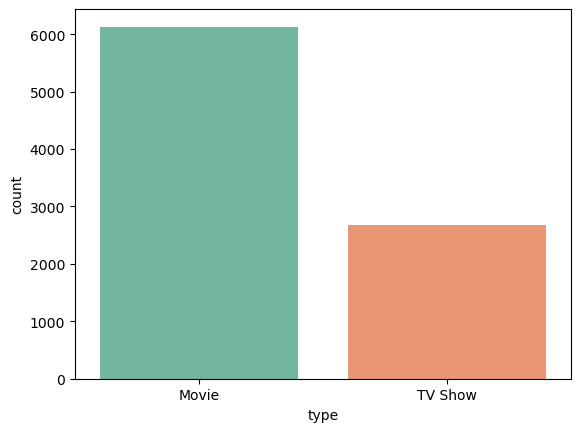

In [41]:
sns.countplot(data=df_all, x='type',hue='type', palette='Set2',legend=False)

The platform offers roughly 2 times as many movies as TV shows (6000~ vs. 2500~ titles).

## Analysis on genres

Text(0.5, 0, 'Genres')

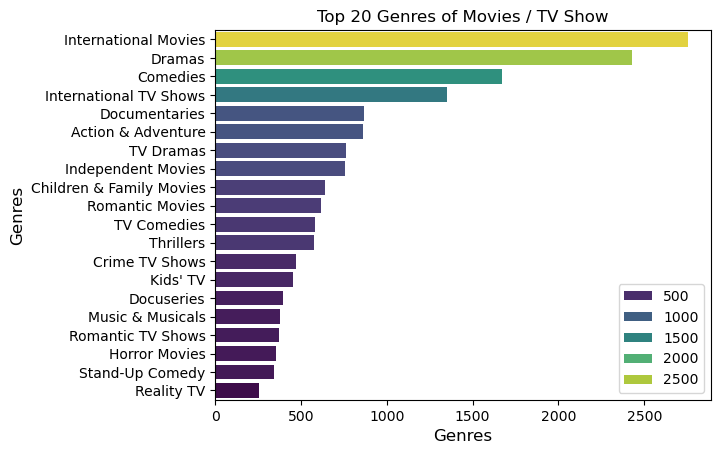

In [40]:
df_genres = df_all[['title', 'listed_in']].copy()
df_genres['listed_in'] = df_genres['listed_in'].fillna('').str.split(', ')
df_genres = df_genres.explode('listed_in')
df_genres = df_genres[df_genres['listed_in'].str.strip() != '']
top_genres = df_genres['listed_in'].value_counts().head(20)

sns.barplot(
    x=top_genres.values,
    hue = top_genres.values,
    y=top_genres.index,
    palette='viridis'
)
plt.title('Top 20 Genres of Movies / TV Show')
plt.ylabel('Genres',fontsize=12)
plt.xlabel('Genres',fontsize=12)

It is evident that International Movies, Dramas, and Comedies accounted for the majority genres in Netflix's catalog.

## Analysis on prodcution countries

Text(0, 0.5, 'Counts')

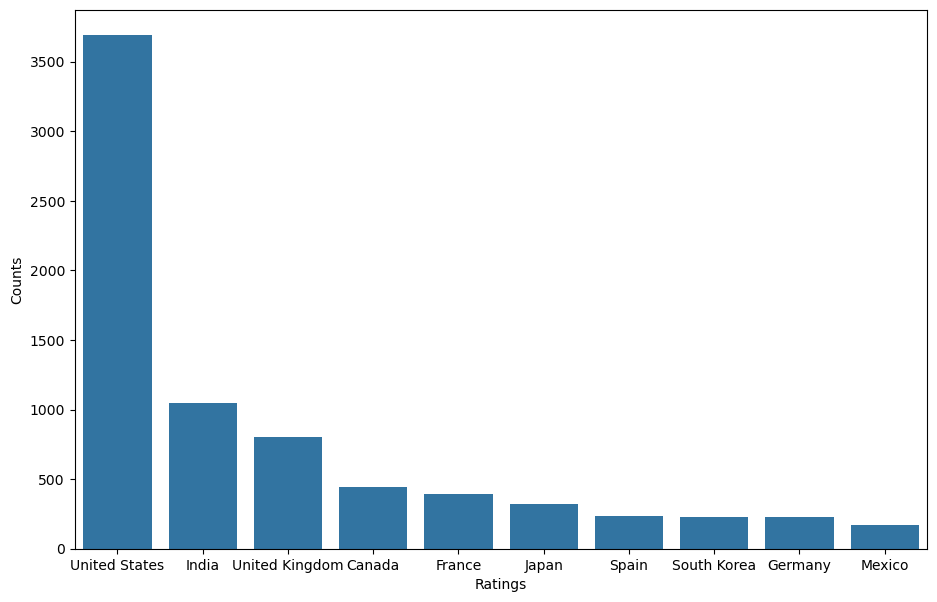

In [52]:
df_country = df_all[['title', 'country']].copy()
df_country['country'] = df_country['country'].fillna('').str.split(', ')
df_country = df_country.explode('country')
df_country = df_country[df_country['country'].str.strip() != '']
top10_country = df_country['country'].value_counts().head(10)

plt.figure(figsize=(11, 7))
rating = pd.Series(top10_country).sort_values(ascending=False)
sns.barplot(top10_country)
plt.xlabel('Ratings')
plt.ylabel('Counts')

United States-made movies dominates the market. 

## Bivariate analysis on country and genre
Looking at the two graphs above, a question naturally arose - **Do some countries prefer production of certain gernres of shows/movies?**

In [10]:
df_combined = pd.merge(df_country, df_genres, on='title', how='inner')
co_occurrence = pd.crosstab(df_combined['country'],df_combined['listed_in'])
top6_country = co_occurrence.loc[['United States', 'India', 'United Kingdom', 'Canada', 'France', 'Japan']]

top6_per_country={}

for country in top6_country.index:
 row = top6_country.loc[country]
 top6_genre = row.nlargest(3)
 top6_per_country[country] = top6_genre
    
top6_per_country = pd.DataFrame(top6_per_country).fillna(0).T
row_sum = top6_country.sum(axis=1)
percentage2 = (top6_per_country.div(row_sum, axis=0)) * 100
percentage2 = percentage2.round(1)
percentage2['Others'] = 100 - percentage2.sum(axis=1)

percentage2

listed_in,Anime Series,British TV Shows,Children & Family Movies,Comedies,Documentaries,Dramas,Independent Movies,International Movies,International TV Shows,Others
United States,0.0,0.0,0.0,10.0,7.5,12.3,0.0,0.0,0.0,70.2
India,0.0,0.0,0.0,11.5,0.0,23.6,0.0,30.8,0.0,34.1
United Kingdom,0.0,12.6,0.0,0.0,0.0,11.0,0.0,9.4,0.0,67.0
Canada,0.0,0.0,9.1,10.7,0.0,9.4,0.0,0.0,0.0,70.8
France,0.0,0.0,0.0,0.0,0.0,18.2,8.0,22.6,0.0,51.2
Japan,19.5,0.0,0.0,0.0,0.0,0.0,0.0,9.8,20.6,50.1


In [11]:
colors = ['#E53935', '#3949AB', '#FFB300', '#43A047' ]

def plot_exploded_donut(ax, row, country_name):
    data = row[row > 0].copy()
    values = data.values
    labels = data.index.tolist()
    explode = [0.12 ,0.12, 0.12] + [0.0]*(len(values)-3)

    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct='%1.0f%%',
        explode=explode,
        colors=colors,
        startangle=90,
        pctdistance=0.80,
        labeldistance=1.05,
        textprops={'fontsize': 10},
        wedgeprops=dict(width=0.50, edgecolor='white'),
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    for text, autotext in zip(texts, autotexts):
        autotext.set_color('white' if float(autotext.get_text().strip('%')) > 5 else 'black')
        autotext.set_fontweight('bold')

    
    ax.set_title(country_name, fontsize=13, pad=10)
    ax.set_aspect('equal')

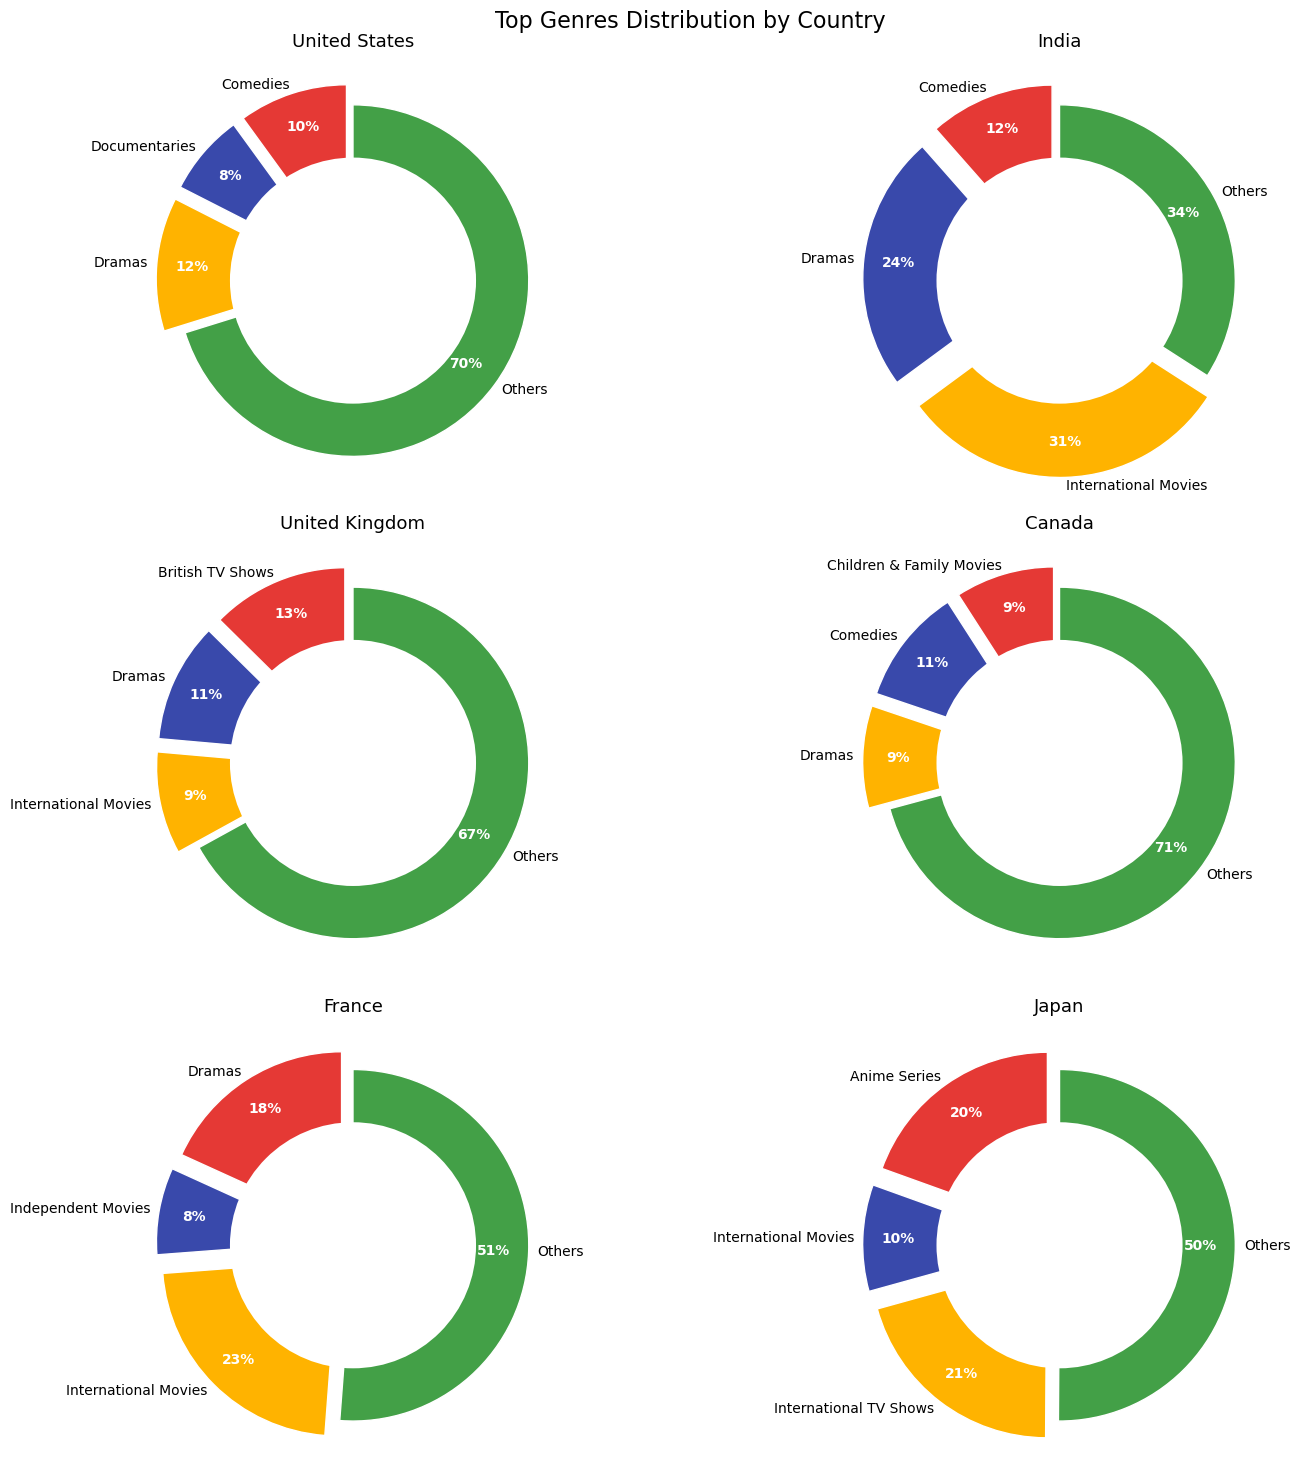

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flat   

for ax, country in zip(axes, percentage2.index):
    plot_exploded_donut(ax, percentage2.loc[country], country)

fig.suptitle("Top Genres Distribution by Country", fontsize=16)
plt.tight_layout()
plt.show()

As observed, most high-production countries exhibit relatively balanced genre distributions, with a large "Others" category (typically 50–71%) indicating broad diversification. However, a few countries show clear specialization.

India stands out with a strong preference for International Movies (31%) and Dramas (24%), followed by Comedies (12%). France also allocates a significant share to International Movies (23%), alongside Dramas (18%) and Independent Movies (8%). Japan displays a distinct profile, with International TV Shows (21%), Anime Series (20%), and International Movies (10%) as key focuses.In contrast, the United States, United Kingdom, and Canada show more even distributions among visible top genres (generally 9–13%), with large "Others" portions dominating.

Notably, Dramas appears among the top visible genres in five of the six countries (ranging from 9% to 24%), underscoring its universal appeal and the enduring demand for narrative-driven storytelling. International Movies also recurs frequently (four out of six countries), highlighting Netflix's strategic push toward globally appealing, often non-English-language cinema.

At the same time, localized strengths remain evident: the United Kingdom dedicates 13% to British TV Shows, catering to domestic and Anglophone audiences, while Japan's deep-rooted animation culture drives approximately one-fifth of its production toward Anime Series, reinforcing anime's strong regional identity and global export potential.

## Analysis of content releasing time

<Axes: xlabel='added_year', ylabel='added_month'>

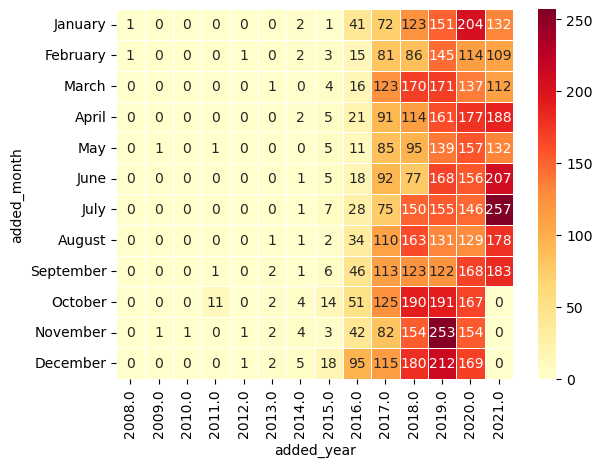

In [13]:
df_all['date_added'] = pd.to_datetime(df_all['date_added'], errors='coerce')
df_all['added_year'] = df_all['date_added'].dt.year
df_all['added_month'] = df_all['date_added'].dt.month_name()

month_order = [ 'January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
heatmap_data = (df_all.groupby(['added_month', 'added_year']).size().unstack(fill_value=0))
heatmap_data = heatmap_data.reindex(index=month_order)
sns.heatmap(heatmap_data,annot=True,fmt='d',cmap='YlOrRd',linewidths=0.5,linecolor='white')

In 2020 shows peak additions in January, with sharp drops in February-March (likely COVID impact). Besides, it is suggested that producers can release new content in Fenruary and May, when relatively much less content was released.

## Rating Analysis

In [14]:
rating = Counter(df_all['rating'])
rating

Counter({'TV-MA': 3207,
         'TV-14': 2160,
         'TV-PG': 863,
         'R': 799,
         'PG-13': 490,
         'TV-Y7': 334,
         'TV-Y': 307,
         'PG': 287,
         'TV-G': 220,
         'NR': 80,
         'G': 41,
         'TV-Y7-FV': 6,
         nan: 4,
         'NC-17': 3,
         'UR': 3,
         '74 min': 1,
         '84 min': 1,
         '66 min': 1})

In [46]:
valid_ratings = ['TV-MA','TV-14','TV-PG','TV-Y','TV-Y7','TV-Y7-FV','TV-G','TV-PG-13','R','PG-13','PG','G','NC-17','NR','UR']
df_all['rating'] = df_all['rating'].where(df_all['rating'].isin(valid_ratings),None)

rating = df_all['rating'].value_counts()
rating

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

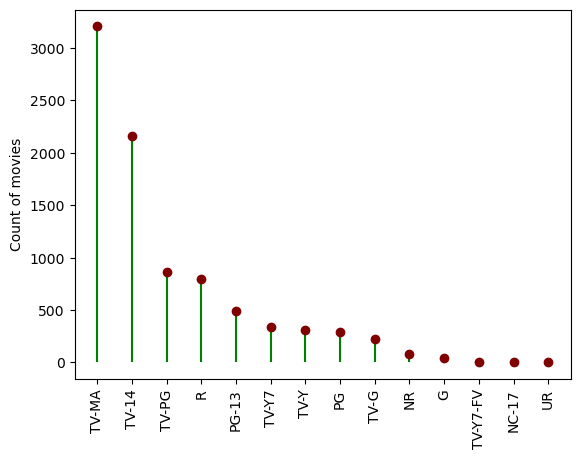

<Figure size 1000x1000 with 0 Axes>

In [50]:
fig, ax = plt.subplots()


fig = plt.figure(figsize = (10, 10))
x=list(rating.index)
y=list(rating.values)
ax.vlines(x, ymin=0, ymax=y, color='green')
ax.plot(x,y, "o", color='maroon')
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation = 90)
ax.set_ylabel("Count of movies")
plt.show()

TV-MA is the most common rating, with over 3200 titles, indicating that Netflix's catalog heavily features content suitable for adults. TV-14 comes the second, showing that teenagers take up a large portion of Netflix's viewers. PG-13,TV-Y7,TV-Y,PG and TV-G are seldomly featured in Netflix's library, suggesting a limited content suitable for chindren or families. The least count goes to UR and NC-17, probably due to the fact that such movies or shows are unsuitable for children under the age of 17.

Overall, most movies and shows are targeted at older teenagers or adults, while family-friendly and kids-oriented content remains underrepresented. The heavy emphasis on mature content may limit appeal to family households and parents seeking age-appropriate options for younger children. Expanding the catalog in the PG, TV-G, TV-Y, and TV-Y7 categories could help attract a broader audience, particularly families, potentially increasing subscriber diversity and watch time across different age groups.

## Duration Analysis

In [17]:
df_all['duration'] = df_all['duration'].astype(str).str.strip()
df_all['duration'].isna().sum()

np.int64(0)

In [18]:
def classify_duration(row):
    dur = row['duration']
    typ = row['type']

    if typ == 'TV Show' or 'Season' in dur:
        if 'Season' in dur:
           try:
               season = dur.split(' ')[0]
               num = int(season)
               if num == 1:
                           return '1 Season'
               elif num == 2:
                             return '2 Seasons'
               else :
                     return '3 Seasons'
           except: 
                  return 'None'
        else:
             return 'None'

    else: 
         try: 
             minutes_str = dur.split()[0]
             time = int(minutes_str)
             if time < 30:
                         return 'Less than 30 minutes'
             elif 30 <= time < 60:
                                  return '30-60 minutes'
             elif 60<= time < 90:
                                 return '60-90 minutes'
             elif 90 <= time < 120:
                                   return '90-120 minutes'
             else: 
                  return 'More than 120 minutes'
         except:
                return 'None'

df_all['duration_group'] = df_all.apply(classify_duration, axis=1)
print(df_all['duration_group'].value_counts())
failed = df_all[df_all['duration_group'] == 'None']

duration_group
90-120 minutes           3092
1 Season                 1793
60-90 minutes            1380
More than 120 minutes    1198
3 Seasons                 458
2 Seasons                 425
30-60 minutes             334
Less than 30 minutes      124
None                        3
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x154ed4550>,
 [Text(-0.9819891734468682, 0.4956785886369682, '90-120 minutes'),
  Text(-0.31992330722078566, -1.05244908546538, '1 Season'),
  Text(0.8170043169445242, -0.7365486719111044, '60-90 minutes'),
  Text(1.08097214088164, 0.2037135995405414, 'More than 120 minutes'),
  Text(0.7841738712358557, 0.7714086722814127, '3 Seasons'),
  Text(0.5065097702356737, 0.9764465436754872, '2 Seasons'),
  Text(0.22680665284062926, 1.0763636663448048, '30-60 minutes'),
  Text(0.04865561412521365, 1.0989233964267475, 'Less than 30 minutes')],
 [Text(-0.6249022012843706, 0.3154318291326161, '35.1%'),
  Text(-0.20358755914049995, -0.6697403271143327, '20.4%'),
  Text(0.5199118380556063, -0.4687127912161572, '15.7%'),
  Text(0.6878913623792253, 0.1296359269803445, '13.6%'),
  Text(0.499019736240999, 0.49089642781544435, '5.2%'),
  Text(0.3223243992408832, 0.6213750732480373, '4.8%'),
  Text(0.1443315063531277, 0.6849586967648758, '3.8%'),
  Text(0.030962663534226866

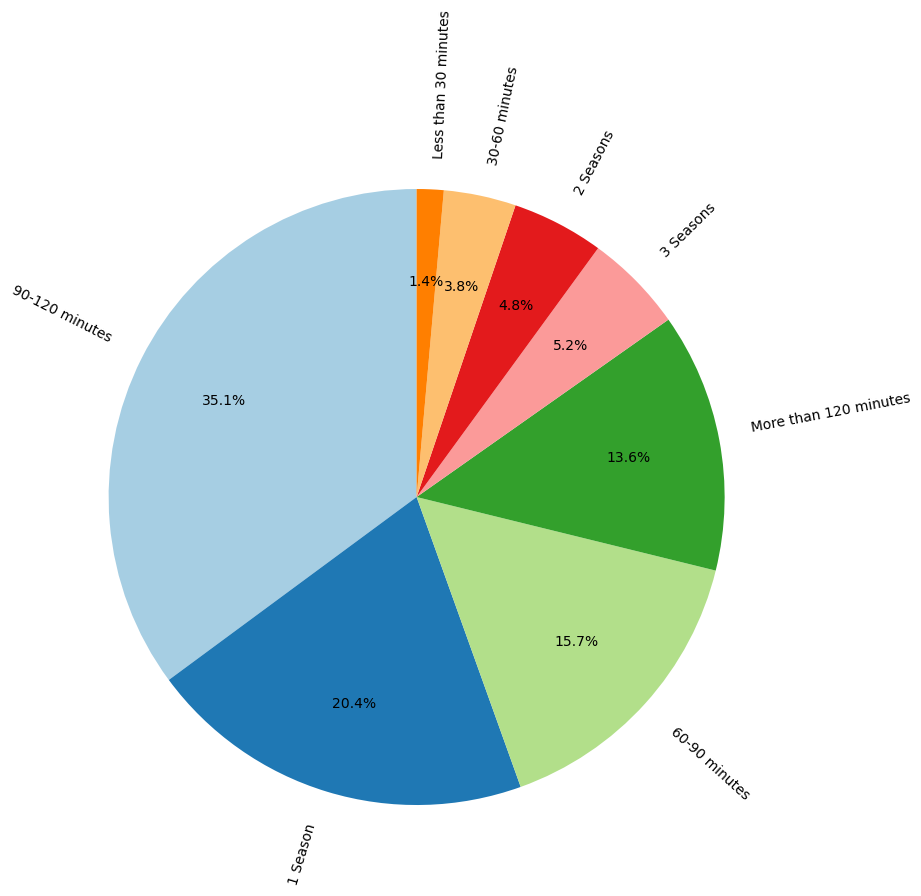

In [19]:
durationcounts = df_all['duration_group'].value_counts().drop('None', errors='ignore')
plt.figure(figsize=(10, 10))  
plt.pie(
    durationcounts.values,
    labels=durationcounts.index,
    autopct='%1.1f%%',         
    startangle=90,              
    colors=plt.cm.Paired(range(len(durationcounts))),  
    pctdistance=0.7,
    rotatelabels=True,
)

One-third of Netflix's content (35.1%) falls into the 90–120 minute range, making it the most common duration category. This suggests that 90–120 minutes is the most preferred length for movies, likely balancing storytelling depth with viewer attention span. TV shows with 1 season rank second (20.4%), followed by 2 seasons (3.8%) and 3+ seasons (5.2%). This distribution indicates a strong preference for shorter or limited-series shows, which are well-suited for binge-watching and lower production risk. Very short content (<30 min) is rare (1–2%), reinforcing that Netflix prioritizes standard-length movies and bingeable TV seasons over micro-content or very long-form programming.`

## Recommendation System (Content-based filtering)

This dataset is primarily textual and with limited numerical features. Besides, we do not have any user ratings or preference data. Hence, the most ideal way to conduct a recommendation system would be through content-based filtering. 

Due to the lack of numerical data, we would choose Cosine Similarity as the bases of our recommendation system. Let's start by considering the description.

In [31]:
df_all['description'] = df_all['description'].fillna('')
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_all['description'])
cosine_sim1 = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_recommendations(title, cosine_sim=cosine_sim1):
    idx = df_all[df_all['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim1[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df_all['title'].iloc[movie_indices]

print('First version: Recommendations on Stranger Things')
print(get_recommendations('Stranger Things'))

First version: Recommendations on Stranger Things
4733                    Rowdy Rathore
8198          The Autopsy of Jane Doe
1240                       Safe Haven
2419                    Big Stone Gap
1487                  Sakho & Mangane
4201                      Hardy Bucks
6518                 Come and Find Me
273                     Gone for Good
5150                      Broadchurch
6639    Dr. Seuss' The Cat in the Hat
Name: title, dtype: object


Apperantly, the results are not satisfactory. Then, I will take 'director', 'cast' and 'genres' into consideration. 

In [32]:
df_all['combined'] = (df_all['description'].fillna('') + ' ' + df_all['director'].fillna('') 
                      + ' ' + df_all['cast'].fillna('') + ' ' + df_all['listed_in'].fillna(''))

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_all['combined'])
cosine_sim2 = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_recommendations(title, cosine_sim=cosine_sim2):
    idx = df_all[df_all['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim2[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df_all['title'].iloc[movie_indices]

print('Second version: Recommendations on Stranger Things')
print(get_recommendations('Stranger Things'))

Second version: Recommendations on Stranger Things
5200            Beyond Stranger Things
1240                        Safe Haven
1487                   Sakho & Mangane
6703                       Equilibrium
2600                        Good Witch
2303                       Warrior Nun
6167       Anjaan: Special Crimes Unit
3632    Sleepless Society: Nyctophobia
4809                     Kiss Me First
2200                             Tread
Name: title, dtype: object


The first recommendation, "Beyond Stranger Things", is a strong and highly relevant match. "Warrior Nun", "Anjaan: Special Crimes Unit", "Sleepless Society: Nyctophobia", and "Kiss Me First" are also reasonably relevant, sharing elements of supernatural themes, mystery, or teen-oriented storytelling.

However, many other recommendations (e.g., Safe Haven, Sakho & Mangane, Good Witch, Equilibrium) fall into completely different genres (romance, crime, light fantasy, dystopian action) with little overlap to Stranger Things' core vibe.

To fix this, I will increase the weighting of genres (listed_in) in the feature combination, since genres are structured and more reliable indicators of content similarity than raw description text alone. This should prioritize titles with matching genres and push more relevant recommendations to the top.

In [33]:
df_nogenres = (df_all['description'].fillna('') + ' ' + df_all['director'].fillna('') + ' ' + df_all['cast'].fillna(''))
tfidf_nogenres = TfidfVectorizer(stop_words='english', max_features=5000)
nogenres_matrix = tfidf.fit_transform(df_nogenres)

df_genresonly=df_all['listed_in'].fillna('')
tfidf_genresonly = TfidfVectorizer(stop_words='english', max_features=5000)
genresonly_matrix = tfidf.fit_transform(df_genresonly)  

combined_matrix = hstack((genresonly_matrix * 0.6, nogenres_matrix * 0.4))
cosine_sim3 = cosine_similarity(combined_matrix,combined_matrix)

def get_recommendations(title, cosine_sim=cosine_sim3):
    idx = df_all[df_all['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim3[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df_all['title'].iloc[movie_indices]

print('Third Version: Recommendations on Stranger Things')
print(get_recommendations('Stranger Things'))

Third Version: Recommendations on Stranger Things
3187                       Nightflyers
1473    Chilling Adventures of Sabrina
6953                             Helix
5287               The Vampire Diaries
241                           Manifest
3986                            The OA
5939                          The 4400
8421                    The Messengers
5200            Beyond Stranger Things
2303                       Warrior Nun
Name: title, dtype: object


In [35]:
print('Third version: Recommendations on Emily in Paris')
print(get_recommendations('Emily in Paris'))

Third version: Recommendations on Emily in Paris
1722                 DASH & LILY
1079    The Baker and the Beauty
5284                 No Tomorrow
1275             Ginny & Georgia
758                    Feel Good
3608             Jane The Virgin
3799         She's Gotta Have It
6646                  Dramaworld
1043               Gilmore Girls
2826                 On My Block
Name: title, dtype: object


After introducing the weight of listed_in (genres), recommendations align much better with core themes. Testing on "Stranger Things" and "Emily in Paris" returned lists of relevant suggestions, successfully capturing shows/movies with similar genres, tones, and content.

However, long descriptions still dominates the scores, introducing noise from common words and causing some irrelevant matches. Moreover, it cannot provide tailored recommendations due to the lack of user history or ratings data. Future improvements could include incorporating collaborative filtering (to leverage user-item interactions if available) and replacing TF-IDF with sentence embeddings (e.g., Sentence Transformers or BERT).